In [1]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split


# Load the dataset
data = fetch_covtype()
X, y = data.data, data.target

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
data

{'data': array([[2.596e+03, 5.100e+01, 3.000e+00, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        [2.590e+03, 5.600e+01, 2.000e+00, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        [2.804e+03, 1.390e+02, 9.000e+00, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        ...,
        [2.386e+03, 1.590e+02, 1.700e+01, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        [2.384e+03, 1.700e+02, 1.500e+01, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        [2.383e+03, 1.650e+02, 1.300e+01, ..., 0.000e+00, 0.000e+00,
         0.000e+00]]),
 'target': array([5, 5, 2, ..., 3, 3, 3]),
 'frame': None,
 'target_names': ['Cover_Type'],
 'feature_names': ['Elevation',
  'Aspect',
  'Slope',
  'Horizontal_Distance_To_Hydrology',
  'Vertical_Distance_To_Hydrology',
  'Horizontal_Distance_To_Roadways',
  'Hillshade_9am',
  'Hillshade_Noon',
  'Hillshade_3pm',
  'Horizontal_Distance_To_Fire_Points',
  'Wilderness_Area_0',
  'Wilderness_Area_1',
  'Wilderness_Area_2',
  'Wildernes

In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier # Logistic regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline: Scaling is often beneficial even for trees to speed up convergence
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('hgb', HistGradientBoostingClassifier(
        max_iter=100,           # Number of boosting rounds
        learning_rate=0.1, 
        max_leaf_nodes=31, 
        early_stopping=True,    # Stop if validation score flattens
        random_state=42
    ))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('hgb',
                 HistGradientBoostingClassifier(early_stopping=True,
                                                random_state=42))])

              precision    recall  f1-score   support

           1       0.77      0.74      0.75     42368
           2       0.78      0.84      0.81     56661
           3       0.78      0.83      0.80      7151
           4       0.75      0.72      0.73       549
           5       0.78      0.51      0.61      1899
           6       0.73      0.45      0.55      3473
           7       0.88      0.68      0.77      4102

    accuracy                           0.78    116203
   macro avg       0.78      0.68      0.72    116203
weighted avg       0.78      0.78      0.78    116203



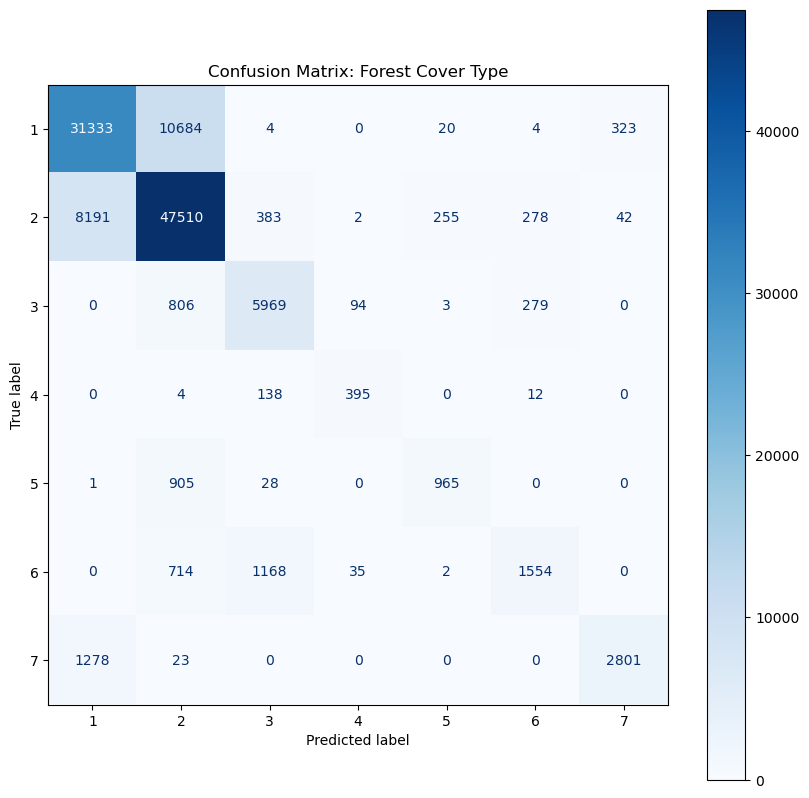

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
y_pred = clf.predict(X_test)

# Comprehensive Report
print(classification_report(y_test, y_pred))

# Visualizing results
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plt.title("Confusion Matrix: Forest Cover Type")
plt.show()

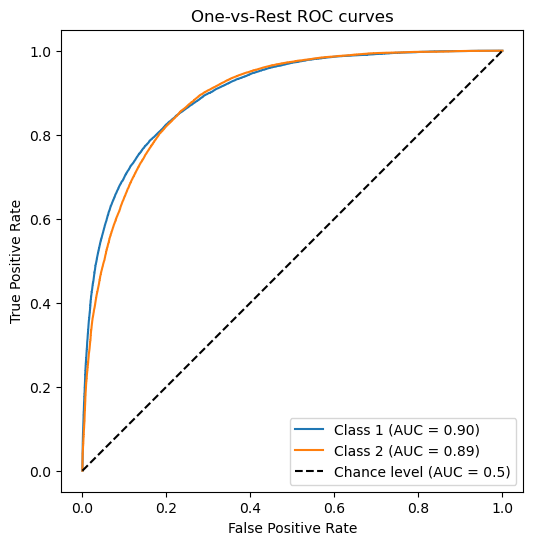

In [9]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# The ROC curve requires probability scores, not just hard labels
y_score = clf.predict_proba(X_test)

# Plotting for specific classes (e.g., Class 1 and Class 2)
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(2): # Plotting first two classes as an example
    RocCurveDisplay.from_predictions(
        (y_test == i + 1).astype(int), # Binary target for current class
        y_score[:, i],
        name=f"Class {i+1}",
        ax=ax
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC curves")
plt.legend()
plt.show()